# Notebook 02 — Exploratory Data Analysis

## Objective
Perform an in-depth exploratory analysis of the IBM HR Analytics dataset to uncover workforce trends, identify factors associated with employee attrition, and generate actionable business insights that will guide feature engineering and predictive modeling.

The objective of this notebook is to explore the IBM HR Analytics dataset through statistical analysis and data visualization to uncover workforce trends, identify factors influencing employee attrition, and generate business insights that will support feature engineering and predictive modeling.

The analysis covers:

- Workforce demographics
- Organizational structure
- Compensation
- Employee experience
- Satisfaction
- Performance
- Attrition patterns
- Correlation analysis
- Outlier detection

In [2]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
df = pd.read_csv("..//data/interim//hr_interim.csv")

In [4]:
df = df.drop(
    columns=[
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

In [5]:
print("Dataset Shape")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 1470
Columns : 32


In [6]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()

remove_columns = [
    "EmployeeNumber",
    "EmployeeCount",
    "StandardHours"
]

numerical_features = [
    column
    for column in numerical_features
    if column not in remove_columns
]

In [8]:
PRIMARY = "#1F77B4"
SECONDARY = "#4E79A7"
SUCCESS = "#2CA02C"
WARNING = "#FF7F0E"
DANGER = "#D62728"
PURPLE = "#9467BD"

## 1. Workforce Demographics

This section explores the demographic composition of the organization's workforce, including age, gender, education, and marital status. Understanding these characteristics provides context for workforce planning and later attrition analysis.

### Age Distribution

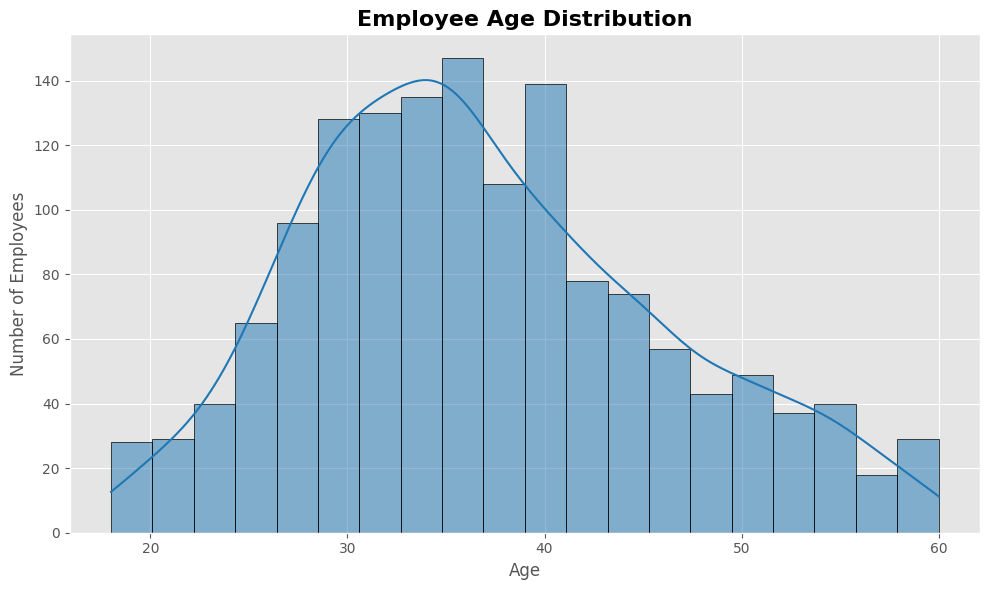

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color=PRIMARY,
    edgecolor="black"
)

plt.title(
    "Employee Age Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

### Gender Distribution

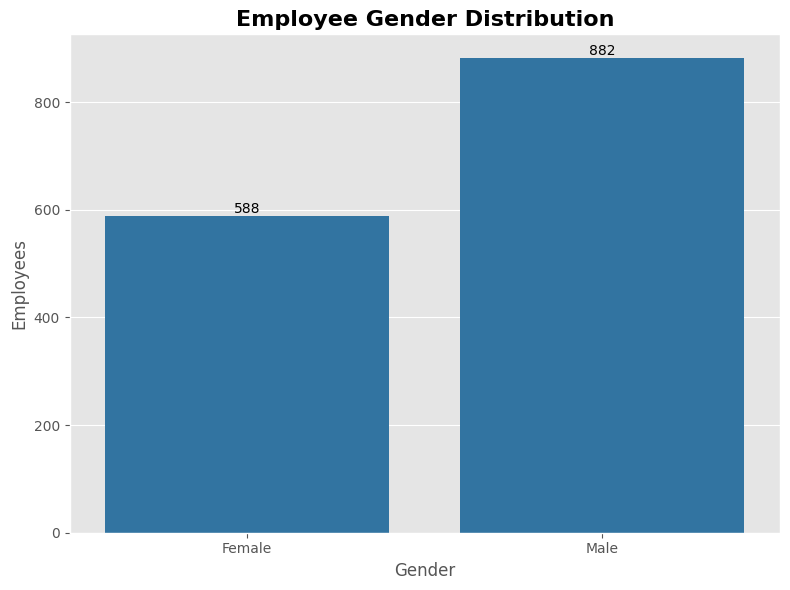

In [11]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x="Gender",
    color=PRIMARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Gender Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Employees")

plt.tight_layout()
plt.show()

### Education Level

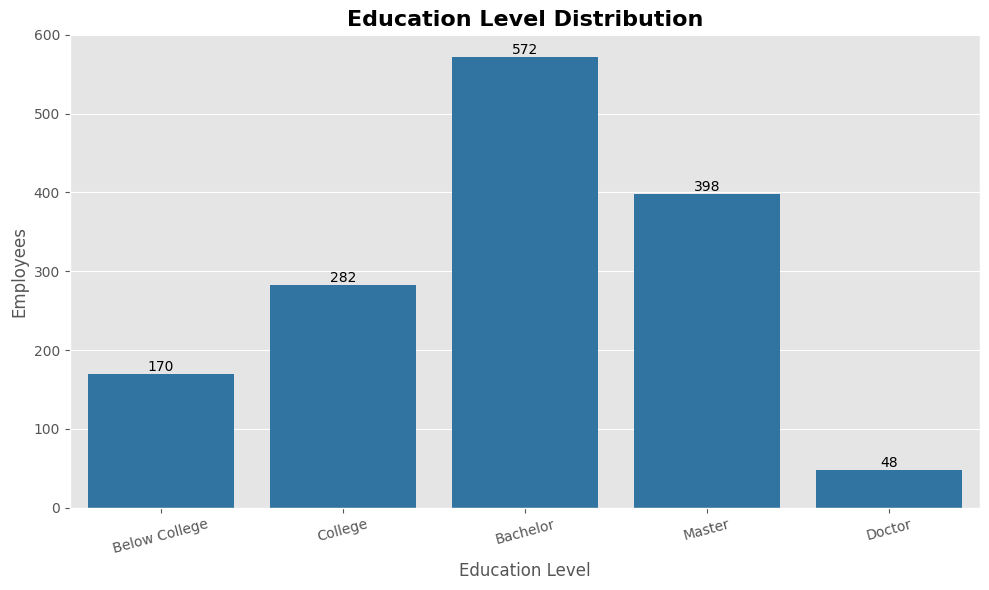

In [12]:
plt.figure(figsize=(10, 6))

education_labels = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

education = df.copy()
education["Education"] = education["Education"].map(education_labels)

ax = sns.countplot(
    data=education,
    x="Education",
    order=[
        "Below College",
        "College",
        "Bachelor",
        "Master",
        "Doctor"
    ],
    color=PRIMARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Education Level Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Education Level")
plt.ylabel("Employees")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Education Field Distribution

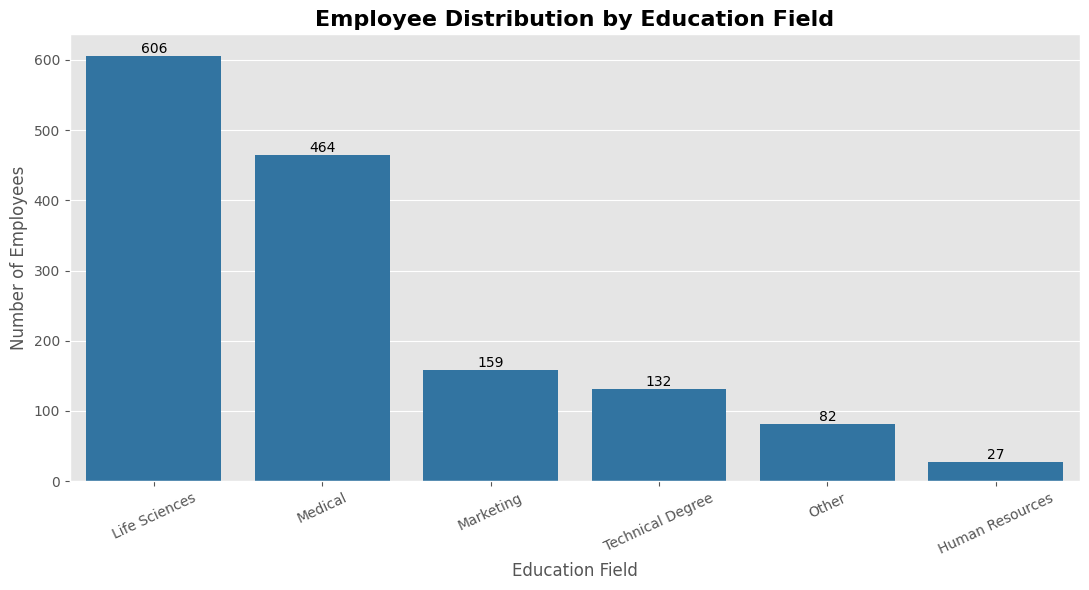

In [13]:
plt.figure(figsize=(11, 6))

ax = sns.countplot(
    data=df,
    x="EducationField",
    order=df["EducationField"].value_counts().index,
    color=PRIMARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Distribution by Education Field",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Education Field")
plt.ylabel("Number of Employees")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

### Marital Status Distribution

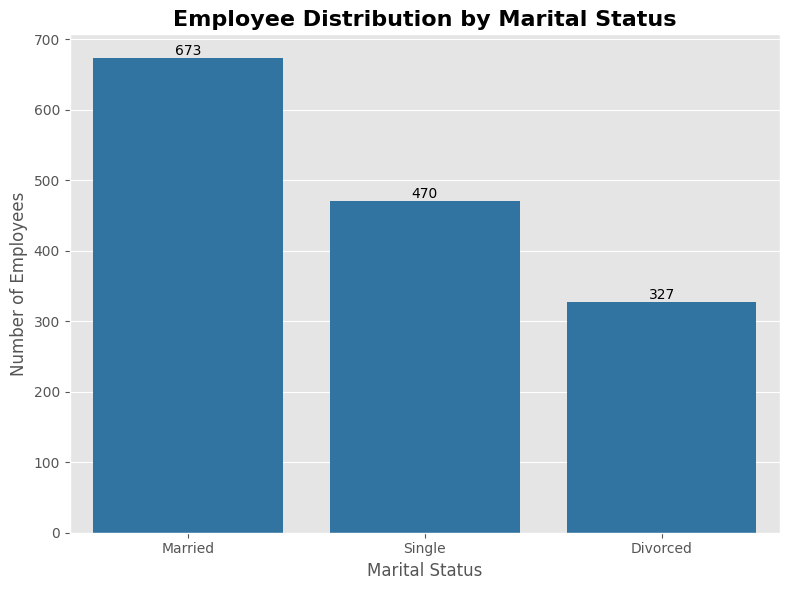

In [14]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x="MaritalStatus",
    order=df["MaritalStatus"].value_counts().index,
    color=PRIMARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Distribution by Marital Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Marital Status")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

# 2. Organization Structure

This section examines how employees are distributed across departments, job roles, job levels, and business travel categories.

Understanding the organizational structure provides valuable context for workforce planning and department-level attrition analysis.

### Department Distribution

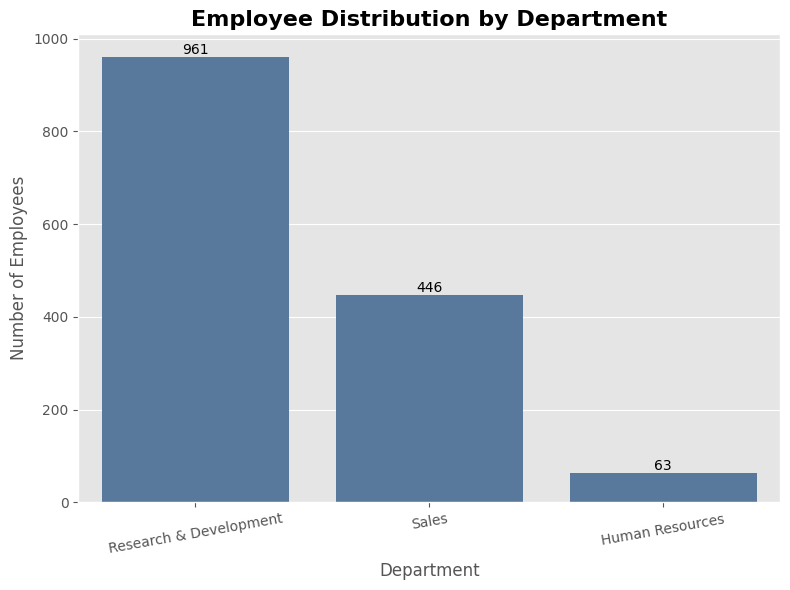

In [15]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x="Department",
    order=df["Department"].value_counts().index,
    color=SECONDARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Distribution by Department",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

### Job Role Distribution

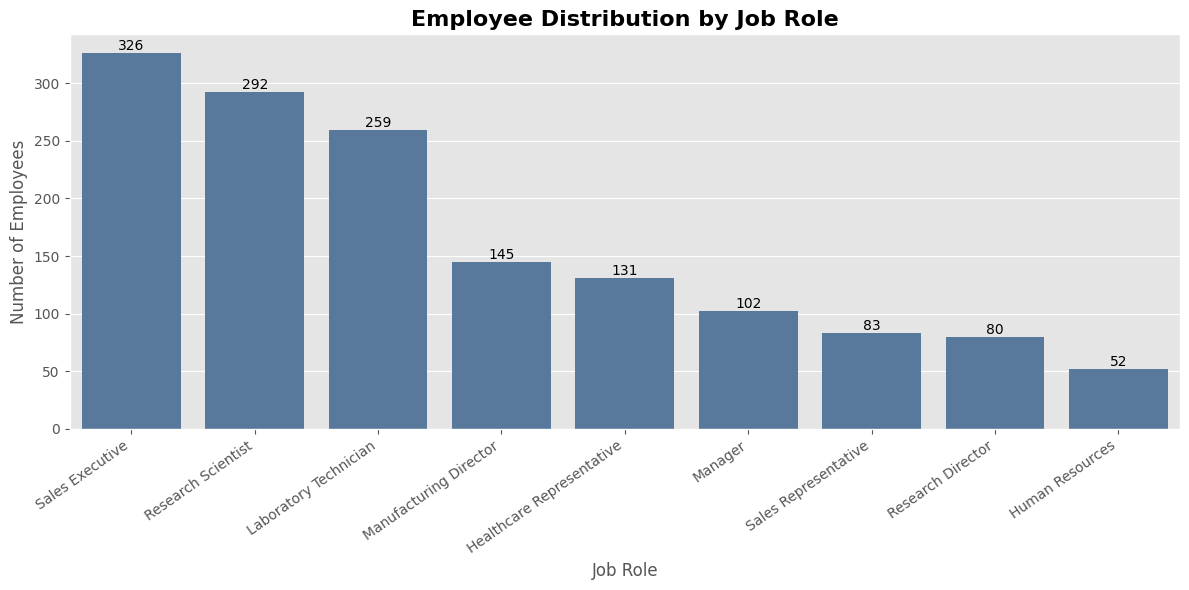

In [16]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="JobRole",
    order=df["JobRole"].value_counts().index,
    color=SECONDARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Distribution by Job Role",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Job Role")
plt.ylabel("Number of Employees")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

### Job Level Distribution

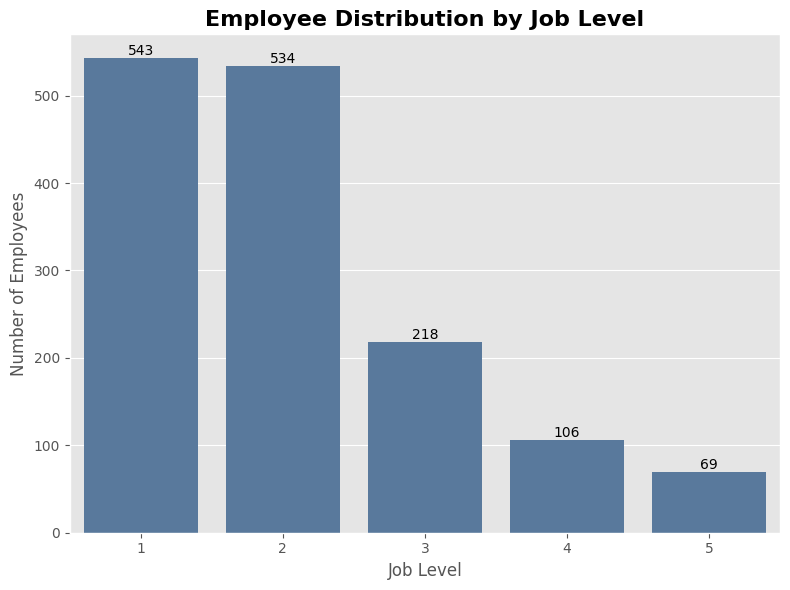

In [17]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x="JobLevel",
    color=SECONDARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Distribution by Job Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Job Level")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

### Business Travel Distribution

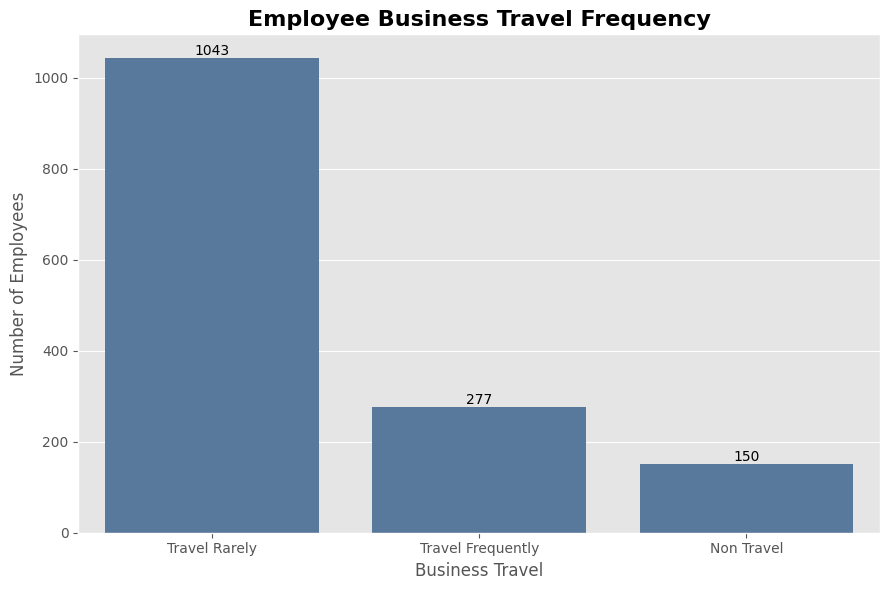

In [18]:
travel_labels = {
    "Travel_Rarely": "Travel Rarely",
    "Travel_Frequently": "Travel Frequently",
    "Non-Travel": "Non Travel"
}

travel = df.copy()
travel["BusinessTravel"] = travel["BusinessTravel"].replace(travel_labels)

plt.figure(figsize=(9,6))

ax = sns.countplot(
    data=travel,
    x="BusinessTravel",
    order=travel["BusinessTravel"].value_counts().index,
    color=SECONDARY
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Business Travel Frequency",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

# 3. Compensation Analytics

Compensation plays a significant role in employee satisfaction, motivation, and retention.

This section explores salary distributions and compensation patterns across departments, job levels, gender, and other workforce dimensions to identify potential disparities and business insights.

### Monthly Income Distribution

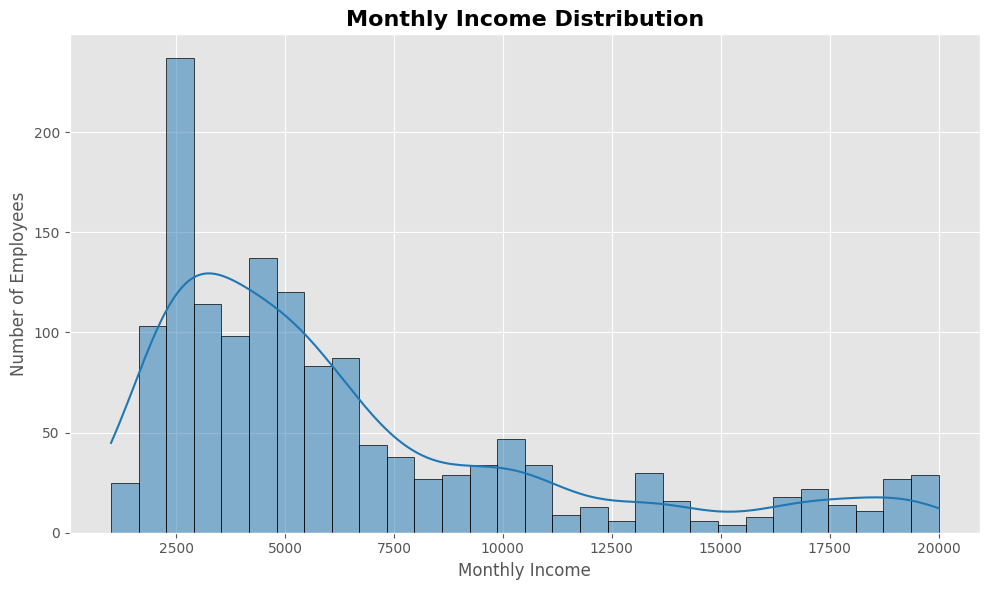

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=30,
    kde=True,
    color=PRIMARY,
    edgecolor="black"
)

plt.title(
    "Monthly Income Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

### Monthly Income Boxplot - Salary Outlier Analysis

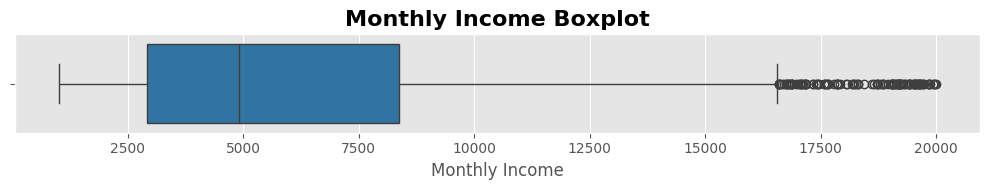

In [20]:
plt.figure(figsize=(10,2))

sns.boxplot(
    data=df,
    x="MonthlyIncome",
    color=PRIMARY
)

plt.title(
    "Monthly Income Boxplot",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Monthly Income")

plt.tight_layout()
plt.show()

### Average Monthly Income by Department

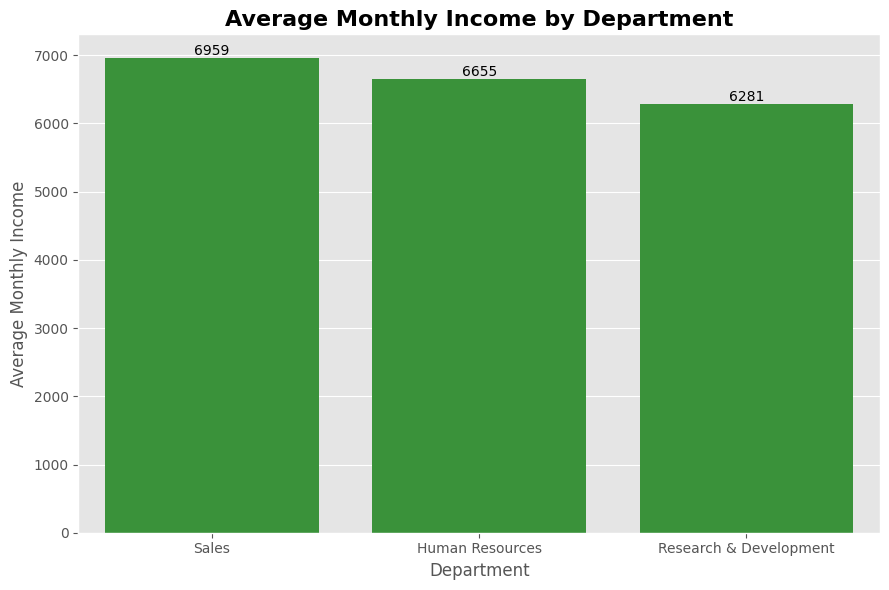

In [21]:
salary_department = (
    df.groupby("Department")["MonthlyIncome"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    x=salary_department.index,
    y=salary_department.values,
    color=SUCCESS
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title(
    "Average Monthly Income by Department",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Department")
plt.ylabel("Average Monthly Income")

plt.tight_layout()
plt.show()

### Monthly Income by Job Level

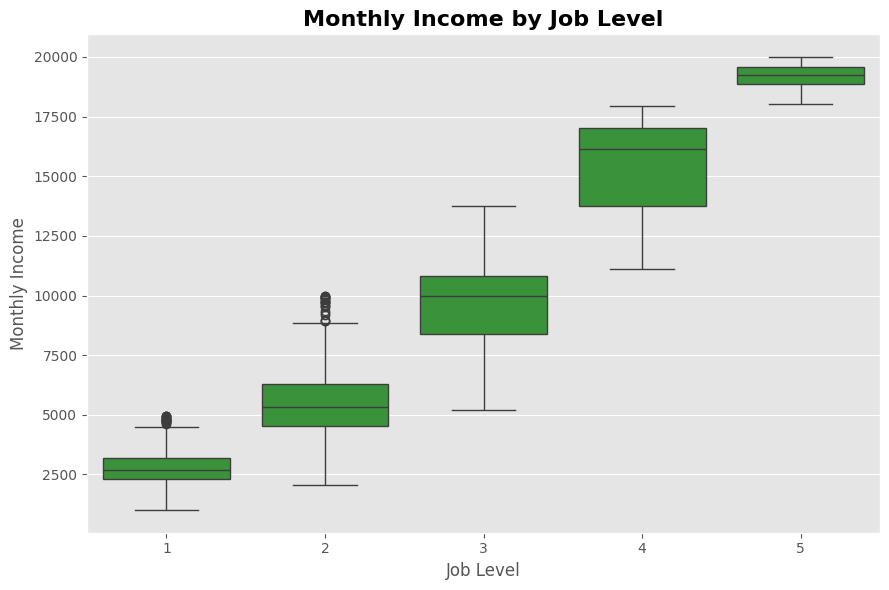

In [22]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="JobLevel",
    y="MonthlyIncome",
    color=SUCCESS
)

plt.title(
    "Monthly Income by Job Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Job Level")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

### Monthly Income by Gender

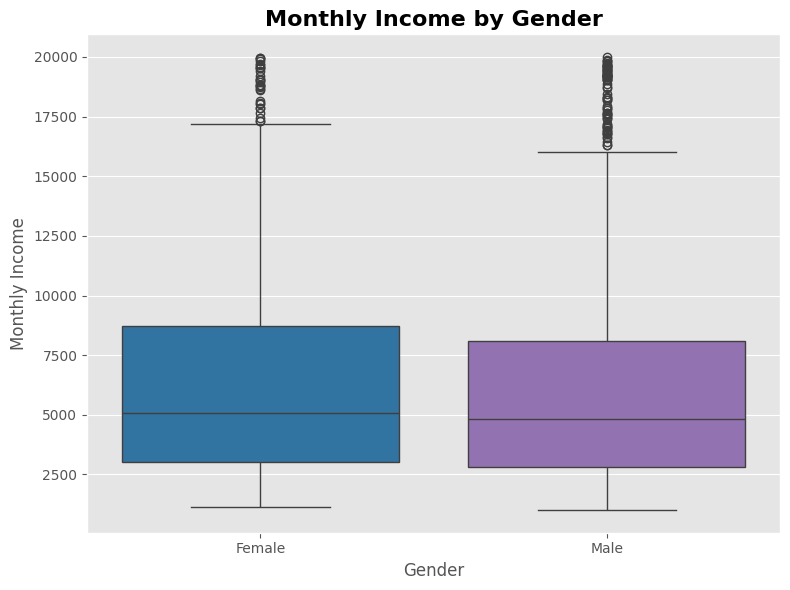

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Gender",
    y="MonthlyIncome",
    palette=[PRIMARY, PURPLE]
)

plt.title(
    "Monthly Income by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

### Monthly Income by Job Role

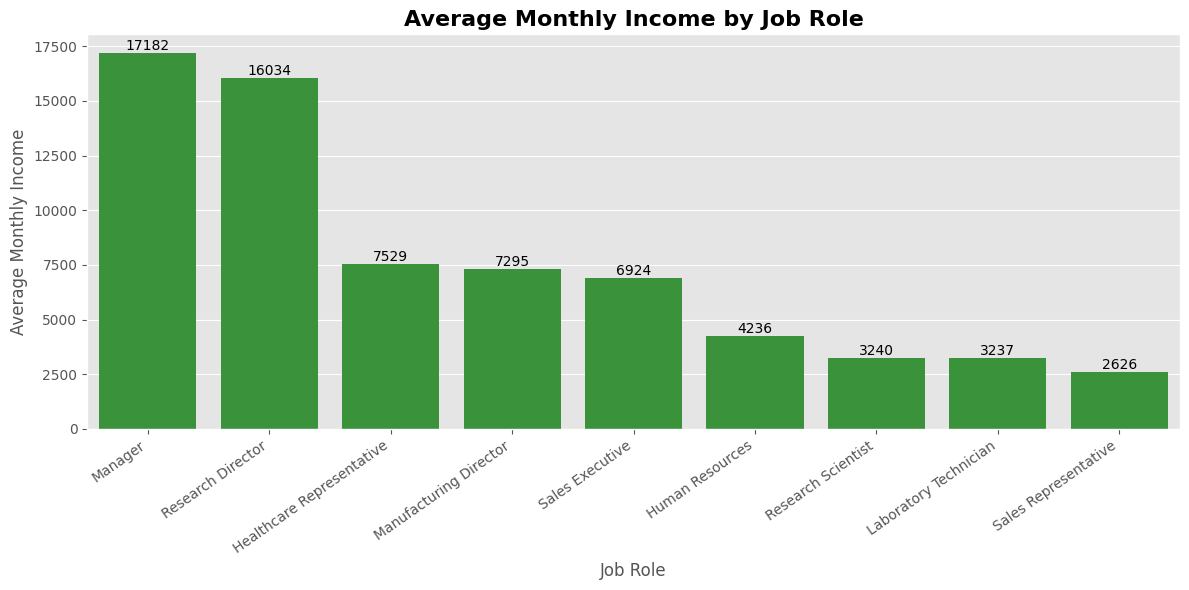

In [24]:
salary_role = (
    df.groupby("JobRole")["MonthlyIncome"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=salary_role.index,
    y=salary_role.values,
    color=SUCCESS
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title(
    "Average Monthly Income by Job Role",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Job Role")
plt.ylabel("Average Monthly Income")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

### Salary Hike Distribution

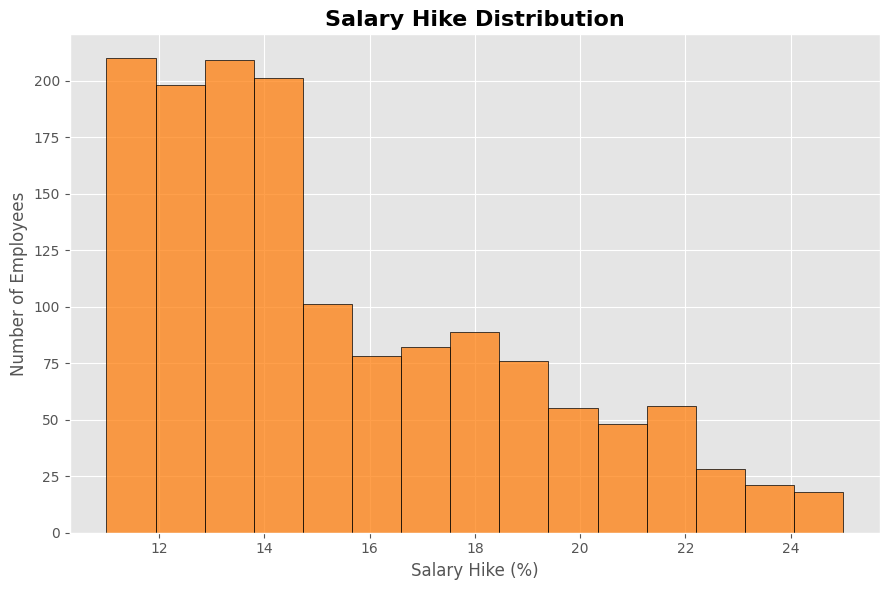

In [25]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=df,
    x="PercentSalaryHike",
    bins=15,
    color=WARNING,
    edgecolor="black"
)

plt.title(
    "Salary Hike Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Salary Hike (%)")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

# Conclusion

The exploratory data analysis provided a comprehensive understanding of the workforce composition and organizational characteristics within the IBM HR Analytics dataset.

Key findings from the analysis include:

- The workforce is primarily composed of employees between 30 and 43 years of age, representing an experienced mid-career employee base.
- Research & Development is the largest department, followed by Sales and Human Resources.
- Compensation increases consistently with job level, indicating a structured salary hierarchy across the organization.
- Most employees possess backgrounds in Life Sciences and Medical disciplines, reflecting the organization's business domain.
- Satisfaction-related variables exhibit healthy variation, making them valuable predictors for employee behavior analysis.
- Salary distributions are positively skewed, with a relatively small number of highly compensated senior employees.
- The dataset demonstrates excellent data quality, with no missing values or duplicate records, allowing subsequent phases to focus entirely on analysis and model development.

Overall, the exploratory analysis establishes a strong understanding of employee demographics, organizational structure, compensation, experience, and workplace characteristics. These findings form the analytical foundation for identifying employee attrition drivers, engineering predictive features, and developing robust machine learning models.

## Next Steps

The next phase focuses on **Employee Attrition Intelligence**, where employee turnover patterns will be investigated across multiple workforce dimensions. This analysis will identify high-risk employee groups, uncover potential retention factors, and generate business insights that will directly inform feature engineering and predictive modeling.

# 4. Employee Attrition Intelligence

Employee attrition is one of the most critical workforce metrics for organizations, directly impacting productivity, recruitment costs, employee morale, and business continuity.

This section investigates how attrition varies across departments, demographics, compensation, work environment, job satisfaction, promotions, overtime, and career progression to uncover the primary drivers of employee turnover.

In [27]:
from pathlib import Path

FIGURES_DIR = Path("../reports/figures")
TABLES_DIR = Path("../reports/tables")

### Overall Attrition Distribution

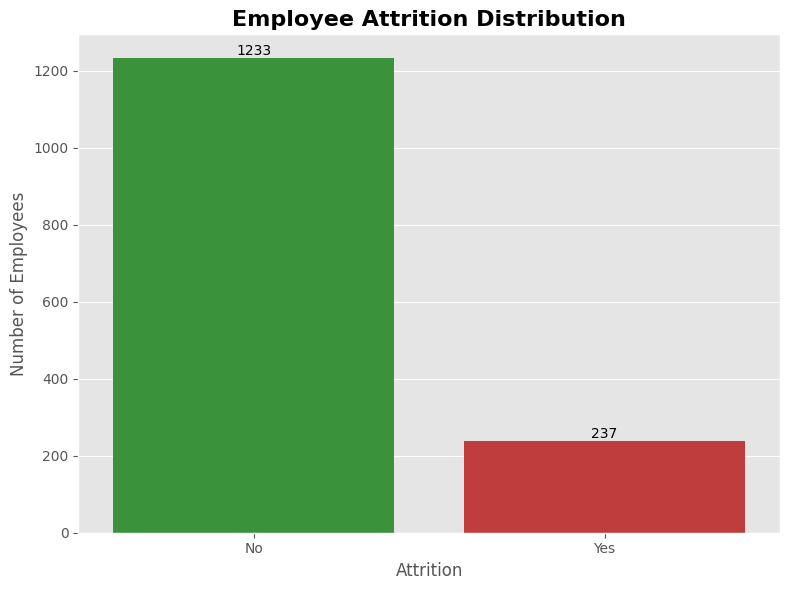

In [28]:
plt.figure(figsize=(8,6))

attrition_counts = df["Attrition"].value_counts()

ax = sns.countplot(
    data=df,
    x="Attrition",
    order=["No","Yes"],
    palette=[SUCCESS, DANGER]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Employee Attrition Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition Rate by Department

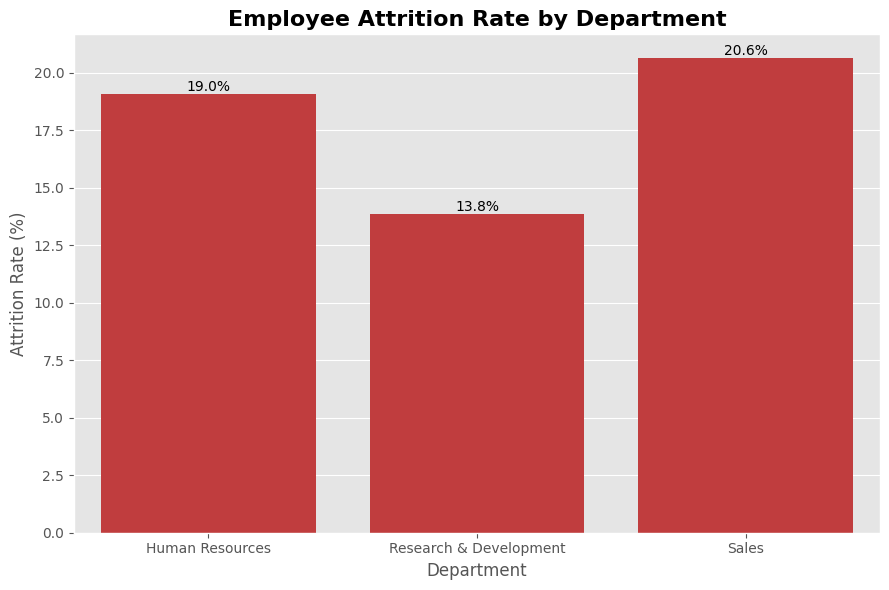

In [29]:
attrition_department = (
    pd.crosstab(
        df["Department"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

attrition_department = attrition_department.reset_index()

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=attrition_department,
    x="Department",
    y="Yes",
    color=DANGER
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Department",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_department.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition by Overtime

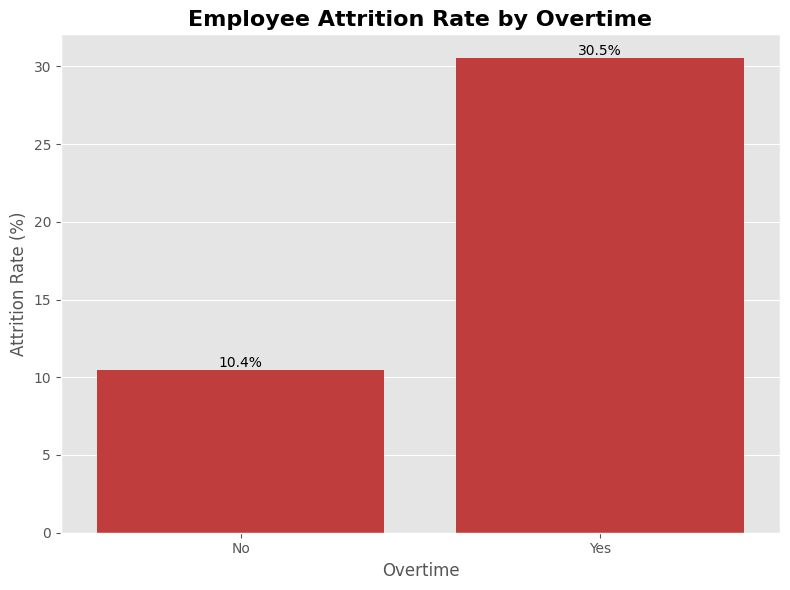

In [30]:
overtime_attrition = (
    pd.crosstab(
        df["OverTime"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

overtime_attrition = overtime_attrition.reset_index()

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=overtime_attrition,
    x="OverTime",
    y="Yes",
    color=DANGER
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Overtime",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_overtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Employee Attrition Rate by Job Role

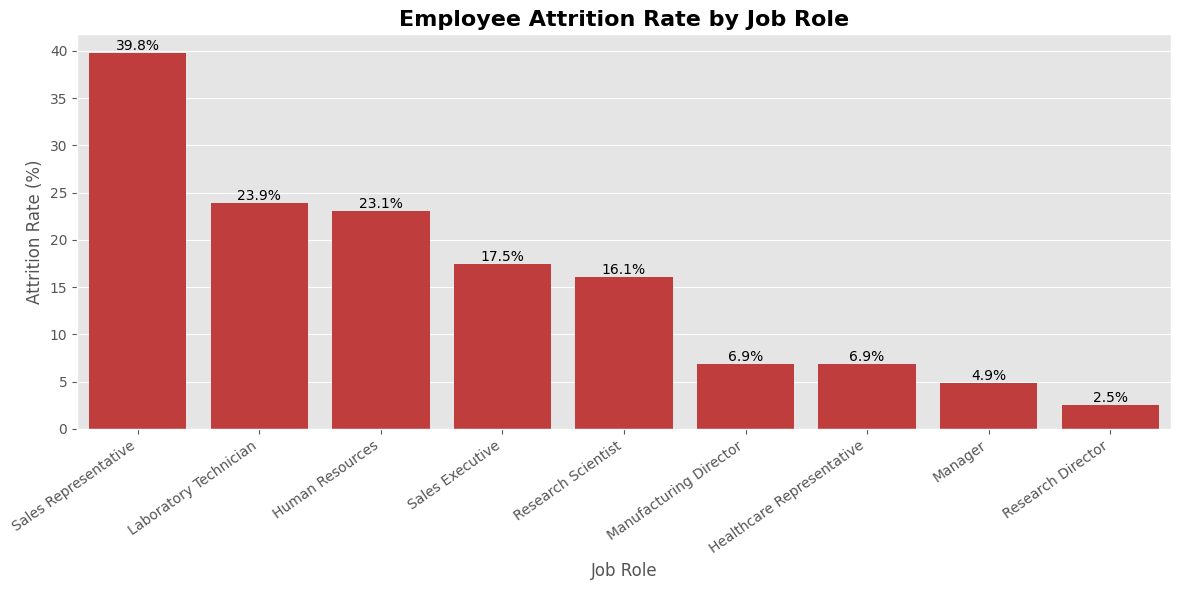

In [31]:
attrition_jobrole = (
    pd.crosstab(
        df["JobRole"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

attrition_jobrole = attrition_jobrole.sort_values(
    by="Yes",
    ascending=False
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=attrition_jobrole,
    x="JobRole",
    y="Yes",
    color=DANGER
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Job Role",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_job_role.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Employee Attrition Rate by Gender

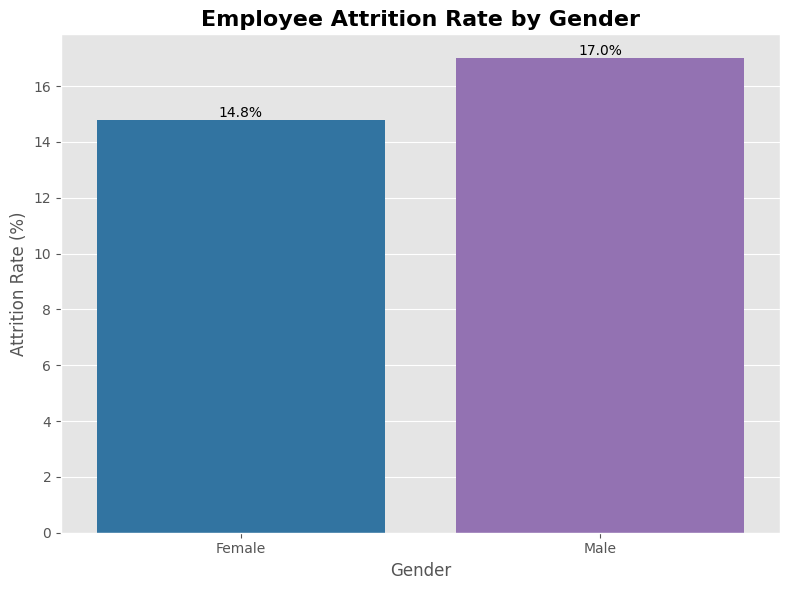

In [32]:
attrition_gender = (
    pd.crosstab(
        df["Gender"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=attrition_gender,
    x="Gender",
    y="Yes",
    palette=[PRIMARY, PURPLE]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Employee Attrition Rate by Marital Status

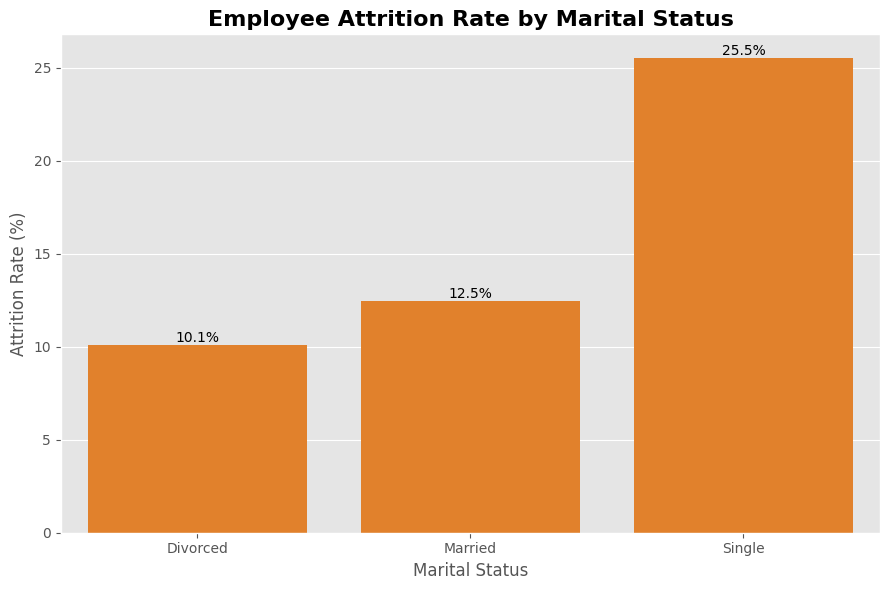

In [33]:
attrition_marital = (
    pd.crosstab(
        df["MaritalStatus"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=attrition_marital,
    x="MaritalStatus",
    y="Yes",
    color=WARNING
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Marital Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Marital Status")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_marital_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Employee Attrition Rate by Education Level

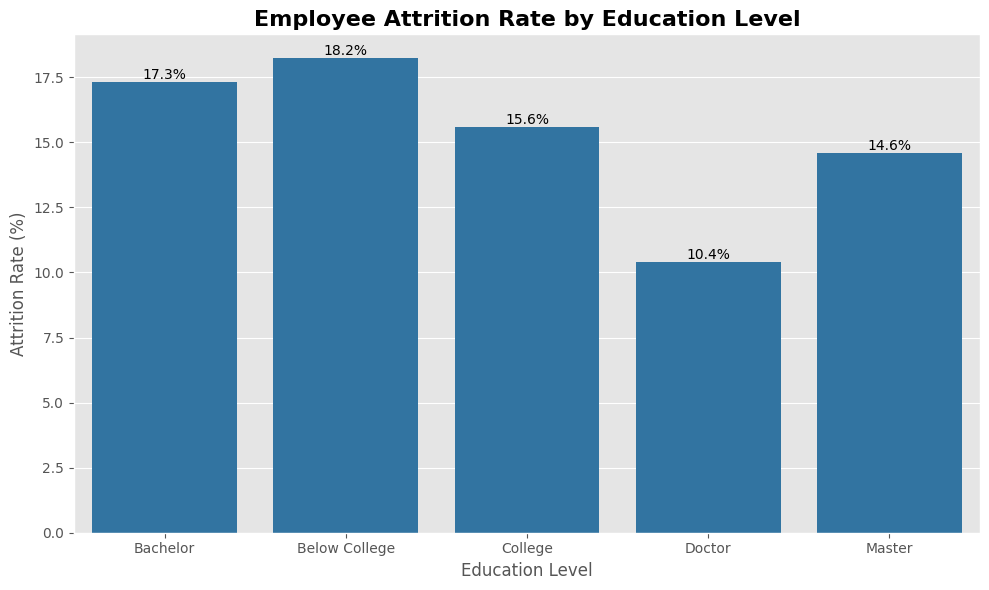

In [34]:
education_labels = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

education_attrition = df.copy()

education_attrition["Education"] = (
    education_attrition["Education"]
    .map(education_labels)
)

attrition_education = (
    pd.crosstab(
        education_attrition["Education"],
        education_attrition["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=attrition_education,
    x="Education",
    y="Yes",
    color=PRIMARY
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Education Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Education Level")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition Rate by Business Travel

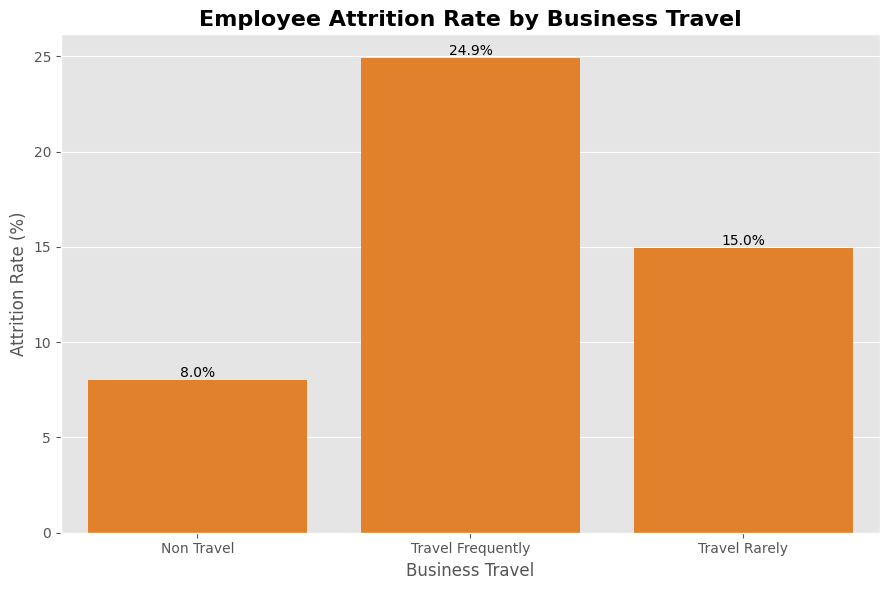

In [35]:
travel = df.copy()

travel["BusinessTravel"] = travel["BusinessTravel"].replace({
    "Travel_Rarely": "Travel Rarely",
    "Travel_Frequently": "Travel Frequently",
    "Non-Travel": "Non Travel"
})

travel_attrition = (
    pd.crosstab(
        travel["BusinessTravel"],
        travel["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=travel_attrition,
    x="BusinessTravel",
    y="Yes",
    color=WARNING
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Business Travel",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_business_travel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition Rate by Age Group

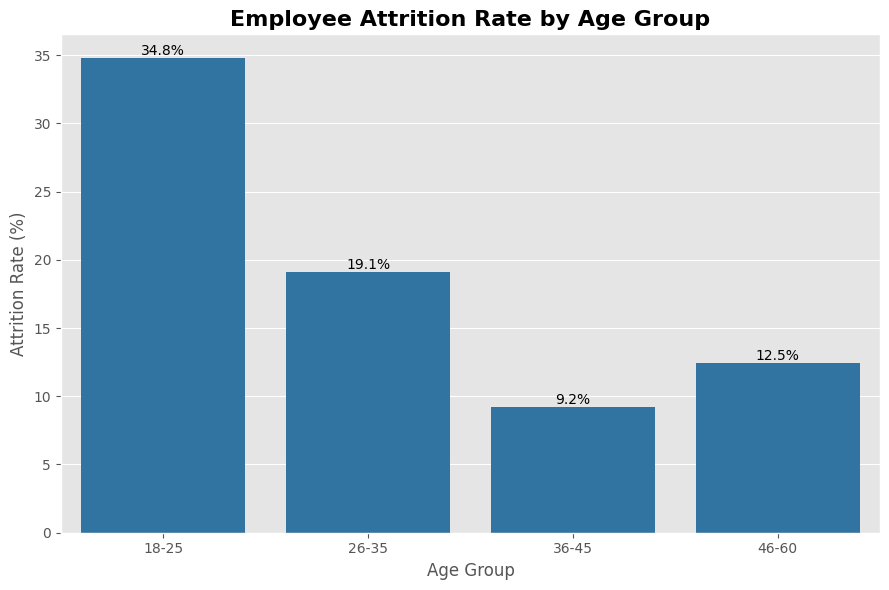

In [36]:
age_df = df.copy()

age_df["AgeGroup"] = pd.cut(
    age_df["Age"],
    bins=[18,25,35,45,60],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-60"
    ]
)

age_attrition = (
    pd.crosstab(
        age_df["AgeGroup"],
        age_df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=age_attrition,
    x="AgeGroup",
    y="Yes",
    color=PRIMARY
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Employee Attrition Rate by Job Satisfaction

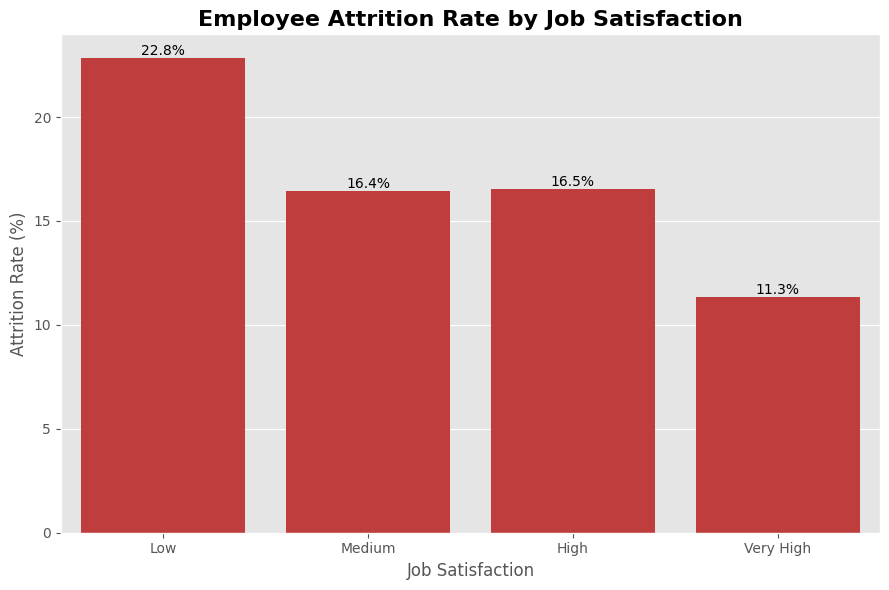

In [37]:
job_satisfaction = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

job_df = df.copy()

job_df["JobSatisfaction"] = (
    job_df["JobSatisfaction"]
    .map(job_satisfaction)
)

attrition_job_satisfaction = (
    pd.crosstab(
        job_df["JobSatisfaction"],
        job_df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

order = ["Low","Medium","High","Very High"]

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=attrition_job_satisfaction,
    x="JobSatisfaction",
    y="Yes",
    order=order,
    color=DANGER
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Job Satisfaction",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_job_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition by Work-Life Balance

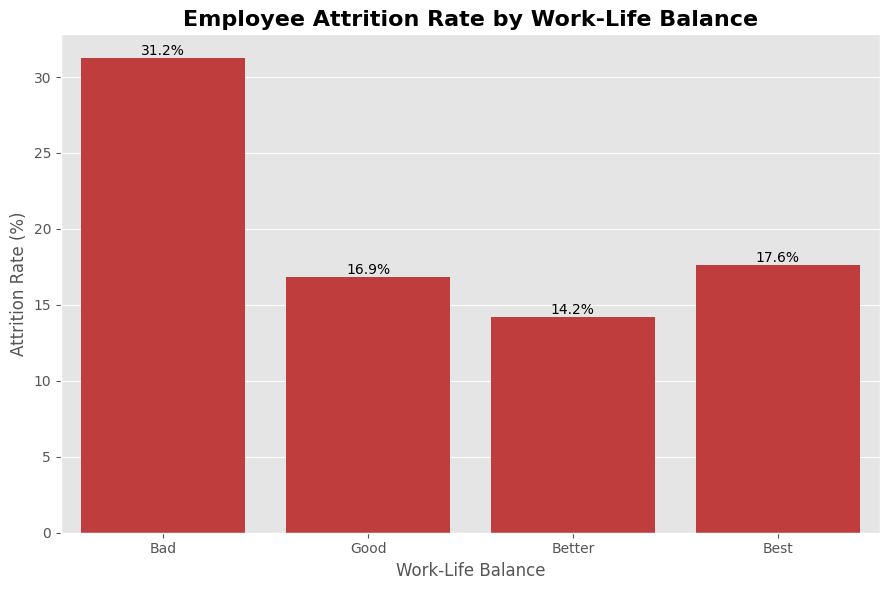

In [38]:
worklife = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

work_df = df.copy()

work_df["WorkLifeBalance"] = (
    work_df["WorkLifeBalance"]
    .map(worklife)
)

attrition_worklife = (
    pd.crosstab(
        work_df["WorkLifeBalance"],
        work_df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

order = ["Bad","Good","Better","Best"]

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=attrition_worklife,
    x="WorkLifeBalance",
    y="Yes",
    order=order,
    color=DANGER
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Work-Life Balance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_work_life_balance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition by Environment Satisfaction

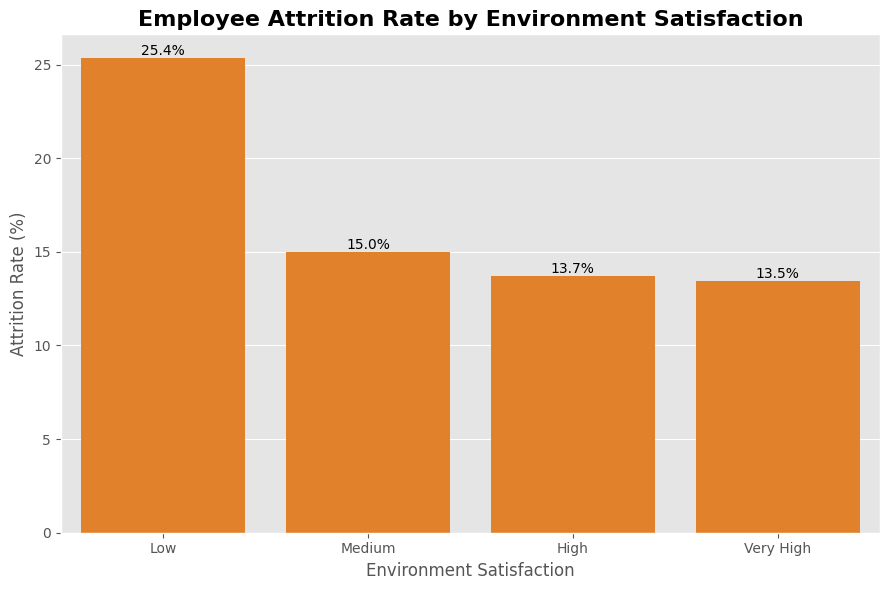

In [39]:
environment = {
    1:"Low",
    2:"Medium",
    3:"High",
    4:"Very High"
}

environment_df = df.copy()

environment_df["EnvironmentSatisfaction"] = (
    environment_df["EnvironmentSatisfaction"]
    .map(environment)
)

attrition_environment = (
    pd.crosstab(
        environment_df["EnvironmentSatisfaction"],
        environment_df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

order = ["Low","Medium","High","Very High"]

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=attrition_environment,
    x="EnvironmentSatisfaction",
    y="Yes",
    order=order,
    color=WARNING
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Environment Satisfaction",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Environment Satisfaction")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_environment_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition by Years Since Last Promotion

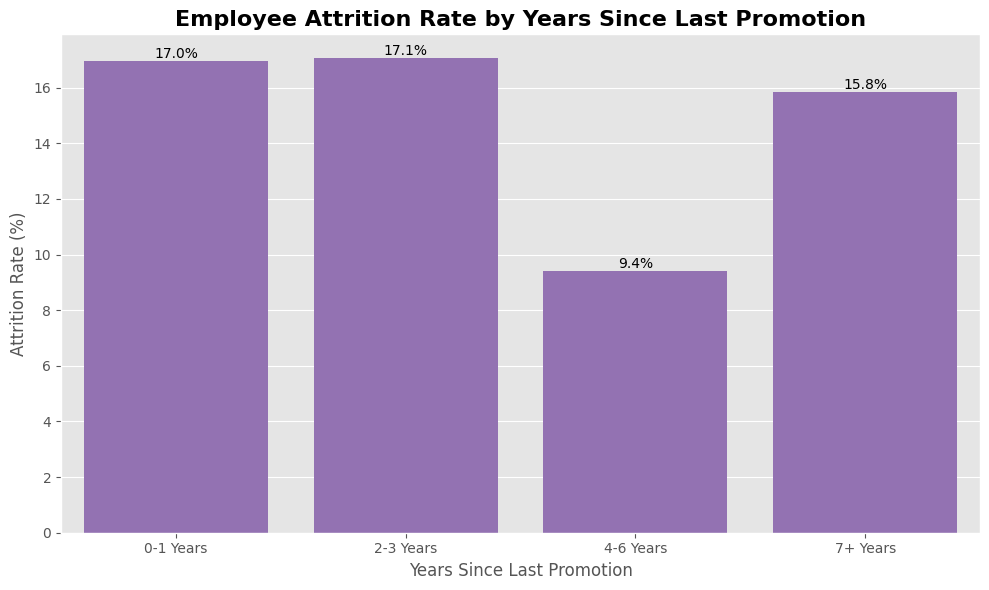

In [40]:
promotion_df = df.copy()

promotion_df["PromotionGroup"] = pd.cut(
    promotion_df["YearsSinceLastPromotion"],
    bins=[-1,1,3,6,15],
    labels=[
        "0-1 Years",
        "2-3 Years",
        "4-6 Years",
        "7+ Years"
    ]
)

promotion_attrition = (
    pd.crosstab(
        promotion_df["PromotionGroup"],
        promotion_df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=promotion_attrition,
    x="PromotionGroup",
    y="Yes",
    color=PURPLE
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Years Since Last Promotion",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_promotion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition by Monthly Income

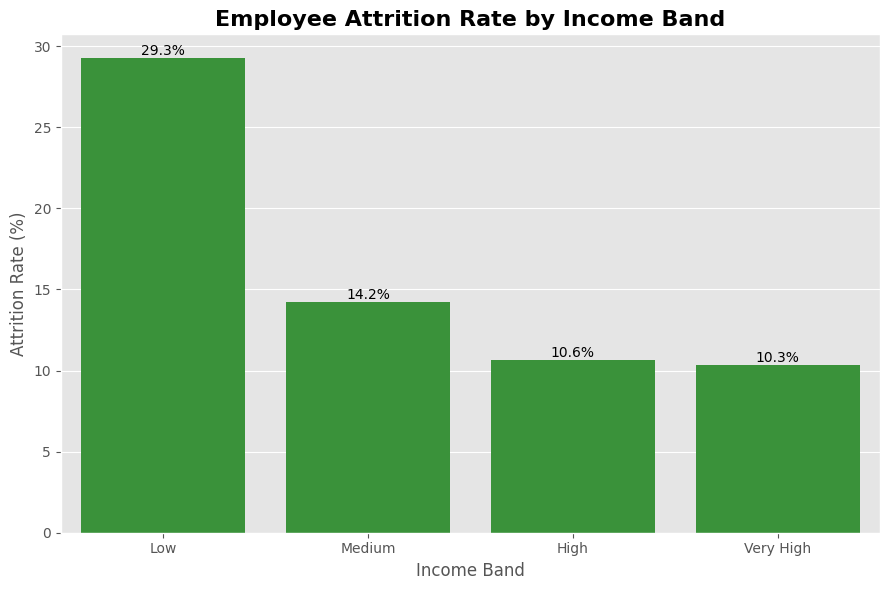

In [41]:
income_df = df.copy()

income_df["IncomeBand"] = pd.qcut(
    income_df["MonthlyIncome"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

income_attrition = (
    pd.crosstab(
        income_df["IncomeBand"],
        income_df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=income_attrition,
    x="IncomeBand",
    y="Yes",
    color=SUCCESS
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Income Band",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Income Band")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_income_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Attrition by Total Working Experience

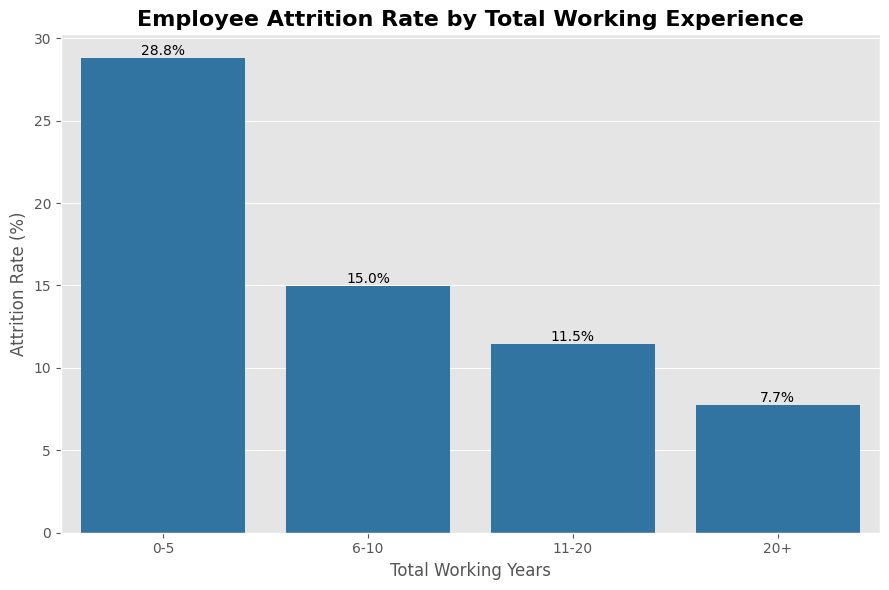

In [42]:
experience_df = df.copy()

experience_df["ExperienceBand"] = pd.cut(
    experience_df["TotalWorkingYears"],
    bins=[0,5,10,20,40],
    labels=[
        "0-5",
        "6-10",
        "11-20",
        "20+"
    ],
    include_lowest=True
)

experience_attrition = (
    pd.crosstab(
        experience_df["ExperienceBand"],
        experience_df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=experience_attrition,
    x="ExperienceBand",
    y="Yes",
    color=PRIMARY
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Employee Attrition Rate by Total Working Experience",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Working Years")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition" / "attrition_by_experience.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# 5. Correlation Analysis

Correlation analysis helps identify linear relationships between numerical variables and provides an initial understanding of how employee characteristics interact with one another.

To include employee attrition in the analysis, the target variable is temporarily encoded as:

- No = 0
- Yes = 1

This encoding is used solely for visualization purposes and does not modify the original dataset.

### Correlation Matrix

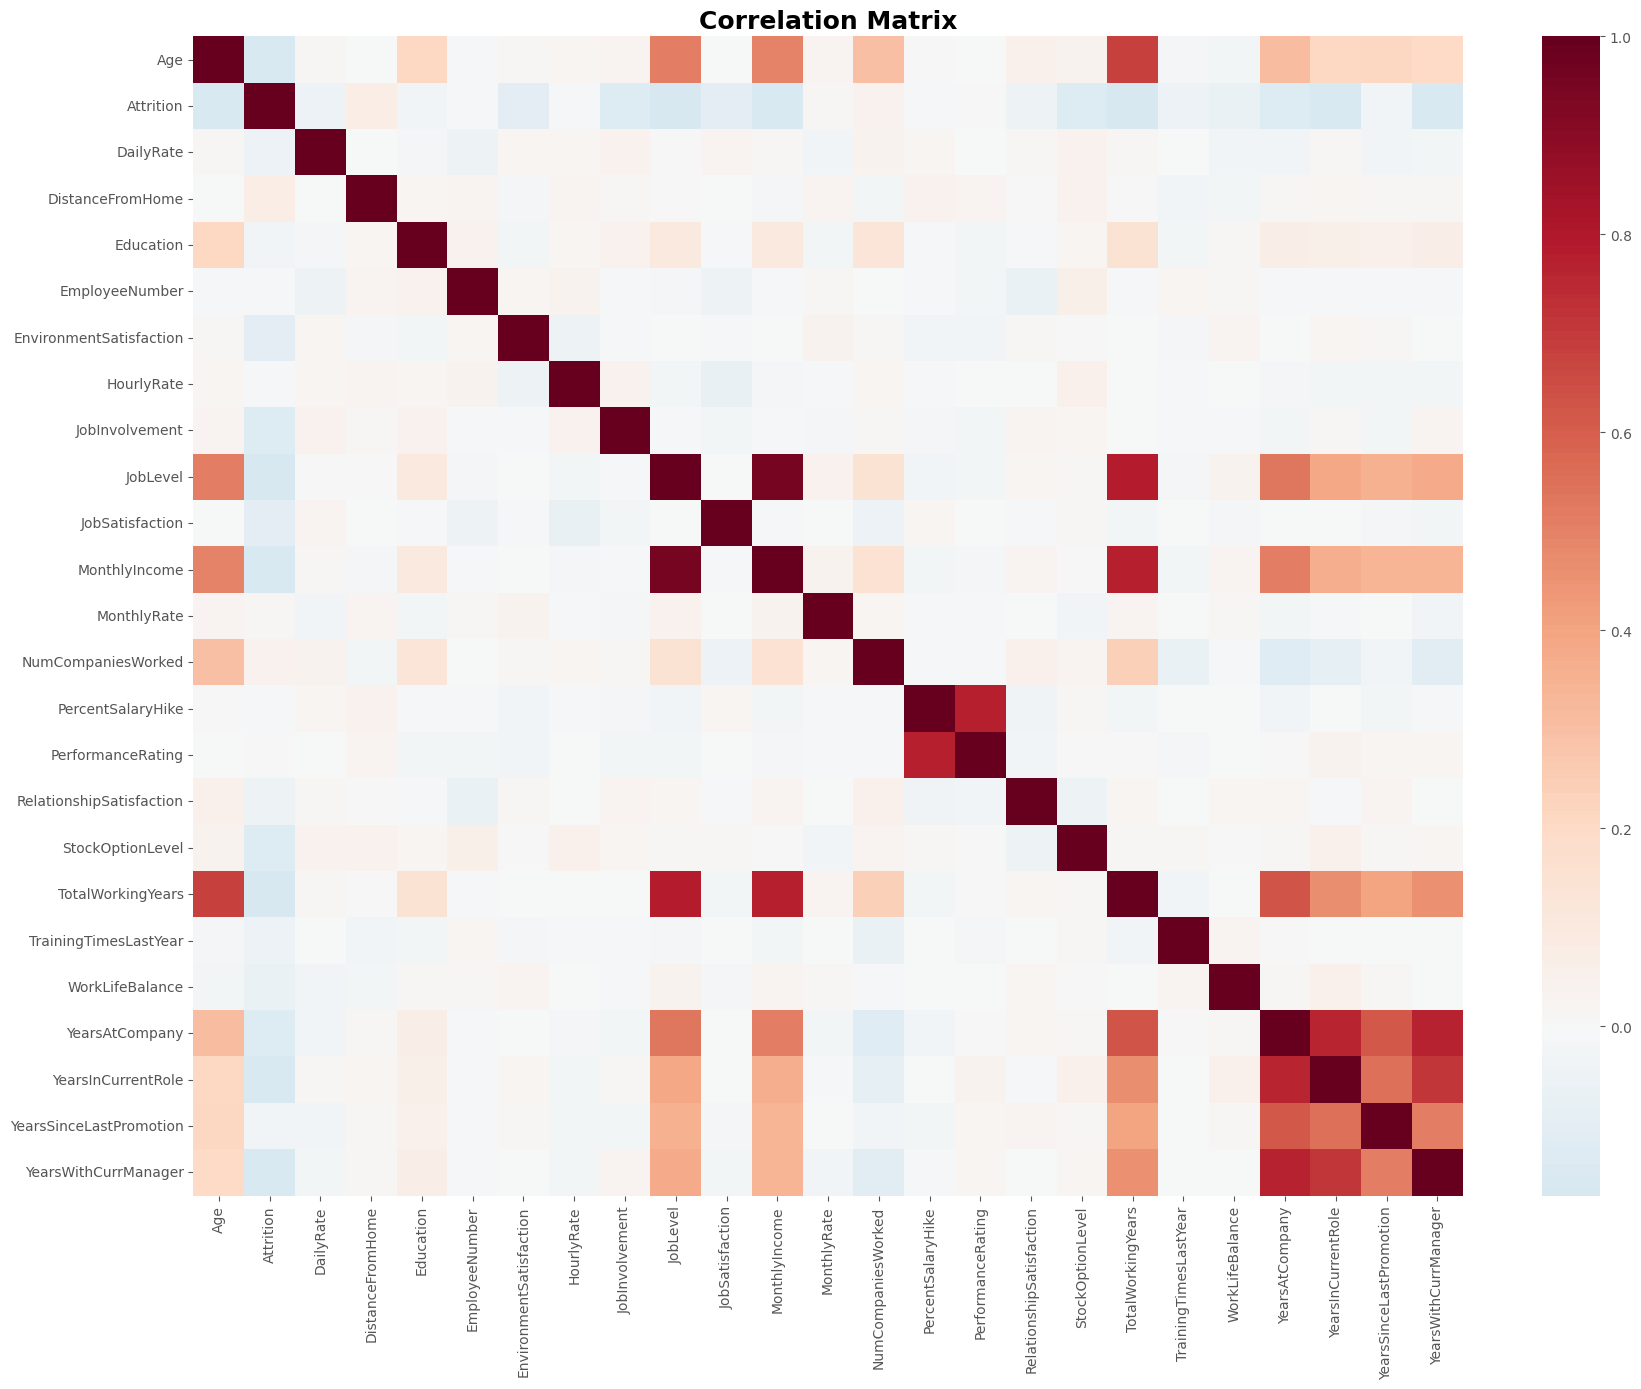

In [43]:
correlation_df = df.copy()

correlation_df["Attrition"] = (
    correlation_df["Attrition"]
    .map({
        "No":0,
        "Yes":1
    })
)

plt.figure(figsize=(18,14))

corr = correlation_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    annot=False
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation" / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Top Features Correlated with Attrition

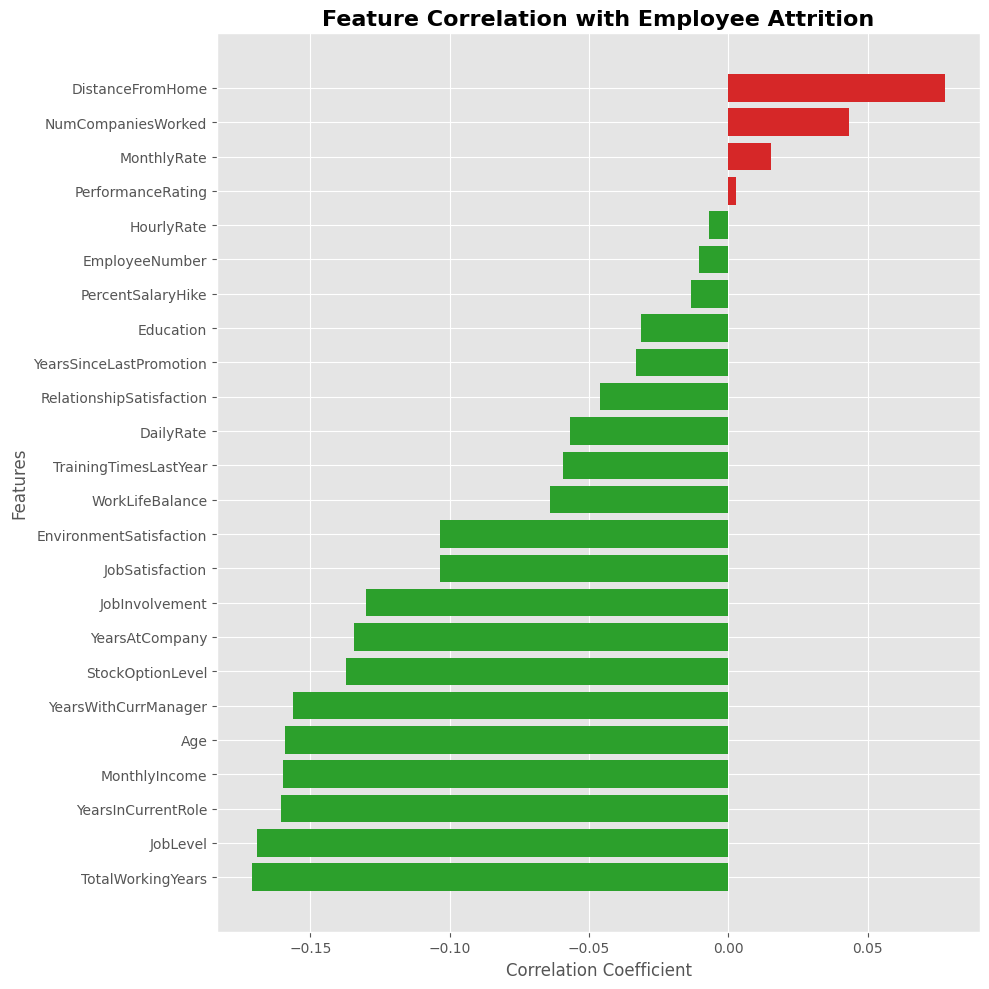

In [44]:
attrition_corr = (
    corr["Attrition"]
    .drop("Attrition")
    .sort_values()
)

plt.figure(figsize=(10,10))

colors = [
    DANGER if value > 0 else SUCCESS
    for value in attrition_corr.values
]

ax = plt.barh(
    attrition_corr.index,
    attrition_corr.values,
    color=colors
)

plt.title(
    "Feature Correlation with Employee Attrition",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation" / "attrition_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Correlation Table

In [45]:
correlation_table = (
    attrition_corr
    .reset_index()
)

correlation_table.columns = [
    "Feature",
    "CorrelationWithAttrition"
]

correlation_table.to_csv(
    TABLES_DIR / "attrition_correlation.csv",
    index=False
)

display(correlation_table)

,Feature,CorrelationWithAttrition
0,TotalWorkingYears,-0.17
1,JobLevel,-0.17
2,YearsInCurrentRole,-0.16
3,MonthlyIncome,-0.16
4,Age,-0.16
5,YearsWithCurrManager,-0.16
6,StockOptionLevel,-0.14
7,YearsAtCompany,-0.13
8,JobInvolvement,-0.13
9,JobSatisfaction,-0.10


# Executive Business Insights

The exploratory data analysis identified several important workforce patterns associated with employee attrition.

## Key Findings

### 1. Overtime is strongly associated with employee attrition.

Employees working overtime exhibit noticeably higher turnover rates, suggesting workload management may be a significant retention factor.

---

### 2. Job satisfaction influences retention.

Employees reporting lower job satisfaction experience substantially higher attrition than those with higher satisfaction levels.

---

### 3. Work-life balance impacts employee retention.

Employees with poor work-life balance demonstrate higher turnover, indicating that employee wellbeing initiatives may improve retention.

---

### 4. Promotion history matters.

Employees who have gone several years without promotion appear more likely to leave the organization.

---

### 5. Certain job roles experience disproportionately high turnover.

Attrition varies considerably across job roles, suggesting role-specific retention strategies may be necessary.

---

### 6. Salary influences attrition.

Employees within lower income bands generally exhibit higher attrition rates than higher-paid employees.

---

### 7. Business travel appears related to employee turnover.

Employees who travel frequently tend to exhibit higher attrition than employees with limited travel requirements.

---

### 8. Workforce demographics alone do not fully explain attrition.

Age, gender, and education contribute useful context but appear less influential than workplace satisfaction, compensation, overtime, and career progression.

---

## Business Recommendation

Organizations seeking to reduce employee attrition should prioritize:

- Reducing excessive overtime
- Improving work-life balance
- Increasing employee engagement
- Creating transparent promotion pathways
- Reviewing compensation for high-risk employee groups
- Monitoring high-risk departments and job roles through HR analytics dashboards

These findings provide the analytical foundation for feature engineering, predictive modeling, explainable AI, and executive decision support in the subsequent phases of the project.

# Notebook Summary

In this notebook, exploratory data analysis transformed raw employee records into actionable workforce intelligence.

The analysis explored employee demographics, organizational structure, compensation, satisfaction, career progression, and attrition patterns while identifying relationships between workforce characteristics and employee turnover.

More than thirty analytical visualizations were created to answer business-focused questions, uncover workforce trends, and generate evidence-based insights for HR decision-making.

The findings from this notebook directly inform the next phase of the project, where advanced feature engineering techniques will be applied before training machine learning and deep learning models to predict employee attrition.